In [9]:
!pip install sentence-transformers seaborn

In [10]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
sentences = [
# Cricket
"Virat Kohli scored a brilliant century in the match",
"The bowler delivered a fast yorker to dismiss the batsman",
"The cricket match went into a thrilling super over",

# Cooking
"I chopped onions and tomatoes for the curry",
"The chef baked a delicious chocolate cake",
"Cooking pasta requires boiling water and adding sauce",

# Cybersecurity
"Cybersecurity protects systems from hackers",
"Phishing emails try to steal sensitive information",
"Strong passwords help protect online accounts",
"Firewalls monitor and control incoming network traffic"
]

In [12]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (10, 384)


In [13]:
similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

similarity_df

,Virat Kohli scored a brilliant century in the match,The bowler delivered a fast yorker to dismiss the batsman,The cricket match went into a thrilling super over,I chopped onions and tomatoes for the curry,The chef baked a delicious chocolate cake,Cooking pasta requires boiling water and adding sauce,Cybersecurity protects systems from hackers,Phishing emails try to steal sensitive information,Strong passwords help protect online accounts,Firewalls monitor and control incoming network traffic
Virat Kohli scored a brilliant century in the match,1.000000,0.421543,0.477389,0.180787,0.155775,0.023527,0.067783,0.051204,0.027046,0.090122
The bowler delivered a fast yorker to dismiss the batsman,0.421543,1.000000,0.391143,0.217128,0.151837,0.027248,-0.020486,0.028597,-0.037895,0.080481
The cricket match went into a thrilling super over,0.477389,0.391143,1.000000,0.117174,0.037871,-0.087308,0.064045,-0.023540,0.018646,0.104409
I chopped onions and tomatoes for the curry,0.180787,0.217128,0.117174,1.000000,0.156347,0.220223,0.027202,0.025217,-0.063109,0.015933
The chef baked a delicious chocolate cake,0.155775,0.151837,0.037871,0.156347,1.000000,0.150744,0.034298,0.125767,-0.025446,0.025602
Cooking pasta requires boiling water and adding sauce,0.023527,0.027248,-0.087308,0.220223,0.150744,1.000000,0.021783,-0.004483,0.008122,0.056490
Cybersecurity protects systems from hackers,0.067783,-0.020486,0.064045,0.027202,0.034298,0.021783,1.000000,0.403776,0.422748,0.240358
Phishing emails try to steal sensitive information,0.051204,0.028597,-0.023540,0.025217,0.125767,-0.004483,0.403776,1.000000,0.383529,-0.018046
Strong passwords help protect online accounts,0.027046,-0.037895,0.018646,-0.063109,-0.025446,0.008122,0.422748,0.383529,1.000000,0.019847
Firewalls monitor and control incoming network traffic,0.090122,0.080481,0.104409,0.015933,0.025602,0.056490,0.240358,-0.018046,0.019847,1.000000


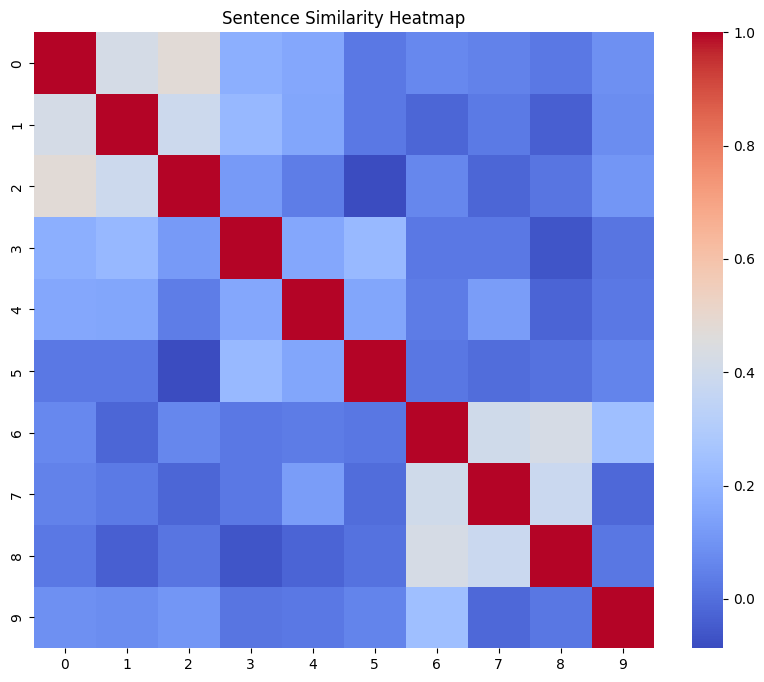

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, cmap="coolwarm")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [15]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(scores)[-2:][::-1]

print("Top 2 similar sentences:\n")

for i in top_indices:
    print(sentences[i])
    print("Similarity score:", scores[i])
    print()

Top 2 similar sentences:

The bowler delivered a fast yorker to dismiss the batsman
Similarity score: 0.5822266

The cricket match went into a thrilling super over
Similarity score: 0.5244911

